# TruthLens: AI Generated News Detection

This notebook trains multiple machine learning and deep learning models to detect misinformation in AI-generated news articles.

## Models Implemented
1. Logistic Regression (Baseline)
2. Convolutional Neural Network (CNN)
3. Bidirectional LSTM (BiLSTM)

## Dataset
AI News Dataset containing news articles with misinformation labels.

In [1]:
!pip install pandas scikit-learn tensorflow nltk -q


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\hariv\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
!pip install pandas scikit-learn transformers datasets torch seaborn matplotlib


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\hariv\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())

OSError: [WinError 1114] A dynamic link library (DLL) initialization routine failed. Error loading "C:\Users\hariv\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\lib\c10.dll" or one of its dependencies.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

import torch
from transformers import DistilBertTokenizerFast
from transformers import DistilBertForSequenceClassification
from transformers import Trainer, TrainingArguments

OSError: [WinError 1114] A dynamic link library (DLL) initialization routine failed. Error loading "C:\Users\hariv\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\lib\c10.dll" or one of its dependencies.

## Load AI News Dataset

In [ ]:
df = pd.read_csv("../data/ai_news/ai_news_extended.csv")
df.head()

,id,post_id,platform,timestamp,date,time,month,weekday,country,city,...,sentiment_score,toxicity_score,model_signature,detected_synthetic_score,embedding_sim_to_facts,factcheck_verdict,external_factchecks_count,source_domain_reliability,engagement,is_misinformation
0,1,P1001,Twitter,2025-10-16 00:00:00,2025-10-16,00:00:00,October,Thursday,India,Delhi,...,0.899,0.751,GPT-like,0.639,0.352,FALSE,2,0.410,1138,0
1,2,P1002,Facebook,2024-04-24 00:00:00,2024-04-24,00:00:00,April,Wednesday,India,Mumbai,...,0.417,0.196,GPT-like,0.909,0.640,TRUE,2,0.854,7993,1
2,3,P1003,Reddit,2024-01-26 00:00:00,2024-01-26,00:00:00,January,Friday,UK,London,...,0.048,0.319,human,0.661,0.589,PARTLY,3,0.478,5679,1
3,4,P1004,Twitter,2026-01-29 00:00:00,2026-01-29,00:00:00,January,Thursday,India,Delhi,...,-0.884,0.957,unknown,0.932,0.781,TRUE,0,0.782,5443,0
4,5,P1005,Twitter,2024-10-08 00:00:00,2024-10-08,00:00:00,October,Tuesday,Brazil,Rio de Janeiro,...,-0.025,0.984,unknown,0.493,0.889,PARTLY,2,0.046,9966,0


## Dataset Overview

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         10000 non-null  int64  
 1   post_id                    10000 non-null  str    
 2   platform                   10000 non-null  str    
 3   timestamp                  10000 non-null  str    
 4   date                       10000 non-null  str    
 5   time                       10000 non-null  str    
 6   month                      10000 non-null  str    
 7   weekday                    10000 non-null  str    
 8   country                    10000 non-null  str    
 9   city                       10000 non-null  str    
 10  timezone                   10000 non-null  str    
 11  author_id                  10000 non-null  str    
 12  author_followers           10000 non-null  int64  
 13  author_verified            10000 non-null  int64  
 14  te

In [ ]:
df.describe()

,id,author_followers,author_verified,text_length,token_count,readability_score,num_urls,num_mentions,num_hashtags,sentiment_score,toxicity_score,detected_synthetic_score,embedding_sim_to_facts,external_factchecks_count,source_domain_reliability,engagement,is_misinformation
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,499112.947700,0.491000,102.118400,21.228100,54.809598,1.515300,2.501600,2.516000,0.009775,0.501457,0.501792,0.495475,2.497900,0.502342,5030.772800,0.50390
std,2886.89568,288634.301486,0.499944,15.275029,6.834467,14.341263,1.114401,1.715661,1.710975,0.577958,0.291003,0.289795,0.289608,1.705604,0.290683,2867.620711,0.50001
min,1.00000,556.000000,0.000000,70.000000,4.000000,30.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,101.000000,0.00000
25%,2500.75000,250018.000000,0.000000,92.000000,16.000000,42.347500,1.000000,1.000000,1.000000,-0.489000,0.252000,0.249000,0.240750,1.000000,0.249750,2548.750000,0.00000
50%,5000.50000,499968.500000,0.000000,99.000000,21.000000,54.830000,2.000000,2.000000,3.000000,0.012000,0.497000,0.506000,0.497500,2.000000,0.503000,5025.500000,1.00000
75%,7500.25000,746279.750000,1.000000,115.000000,27.000000,67.000000,3.000000,4.000000,4.000000,0.517000,0.760000,0.757000,0.744000,4.000000,0.757000,7498.250000,1.00000
max,10000.00000,999979.000000,1.000000,141.000000,41.000000,79.990000,3.000000,5.000000,5.000000,1.000000,1.000000,1.000000,1.000000,5.000000,1.000000,9999.000000,1.00000


## Selecting Relevant Features

In [ ]:
df = df[['text','is_misinformation']]
df = df.rename(columns={'is_misinformation':'label'})
df = df.dropna()
df.head()

,text,label
0,New study: Using ChatGPT increases your chance...,0
1,Conspiracy exposed: AI is behind the rise in g...,1
2,Whistleblower: Google AI is suppressing conser...,1
3,Truth revealed: All those 'AI-generated art' p...,0
4,Shocking: AI chatbots are secretly manipulatin...,0


## Class Distribution

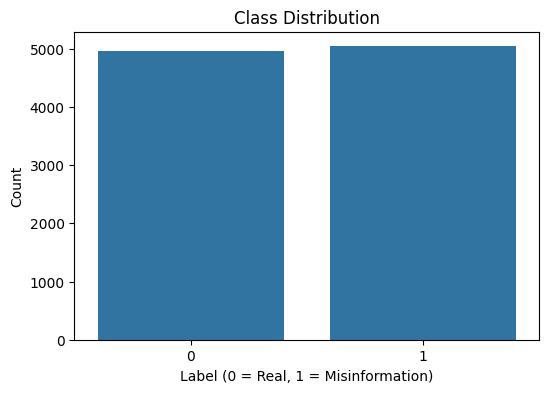

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['label'])
plt.title("Class Distribution")
plt.xlabel("Label (0 = Real, 1 = Misinformation)")
plt.ylabel("Count")
plt.show()

## Text Length Distribution

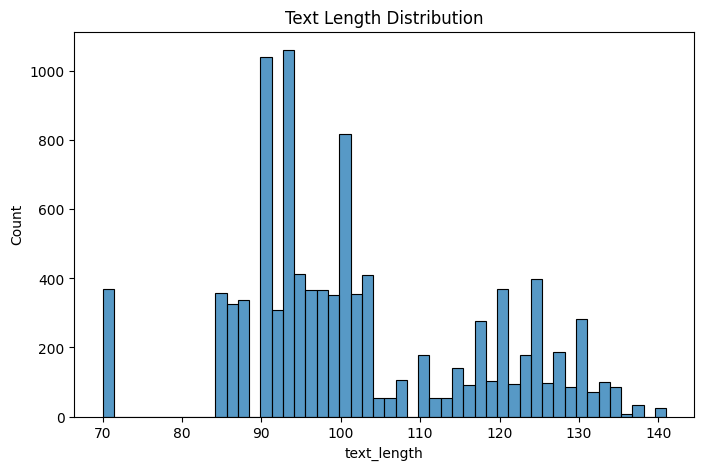

In [ ]:
df['text_length'] = df['text'].apply(len)
plt.figure(figsize=(8,5))
sns.histplot(df['text_length'], bins=50)
plt.title("Text Length Distribution")
plt.show()

## Word Count Analysis

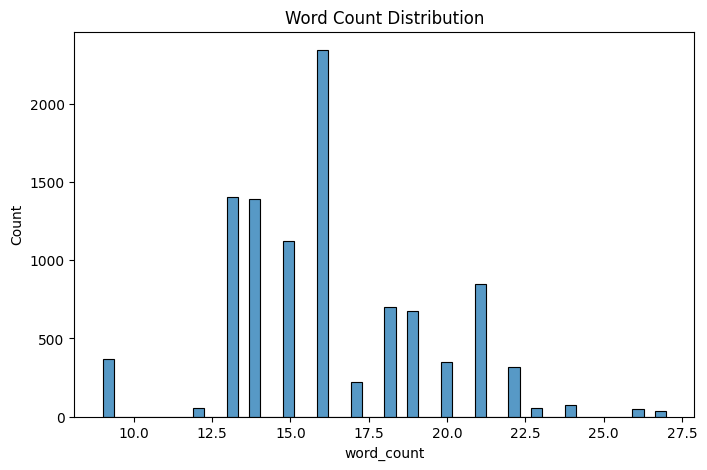

In [ ]:
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
plt.figure(figsize=(8,5))
sns.histplot(df['word_count'], bins=50)
plt.title("Word Count Distribution")
plt.show()

## Average Word Count by Label

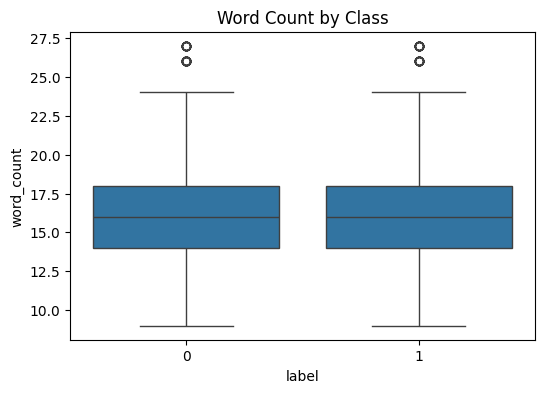

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['label'], y=df['word_count'])
plt.title("Word Count by Class")
plt.show()

## Train Test Split

In [ ]:
X = df['text']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

# Logistic Regression Model
Baseline Machine Learning Model

In [ ]:
# TF-IDF Vectorization

vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [ ]:
# Logistic Regression Model

lr_model = LogisticRegression()
lr_model.fit(X_train_tfidf,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
# Prediction
pred_lr = lr_model.predict(X_test_tfidf)
print(classification_report(y_test,pred_lr))

              precision    recall  f1-score   support

           0       0.49      0.43      0.46       973
           1       0.52      0.57      0.54      1027

    accuracy                           0.50      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.50      0.50      0.50      2000



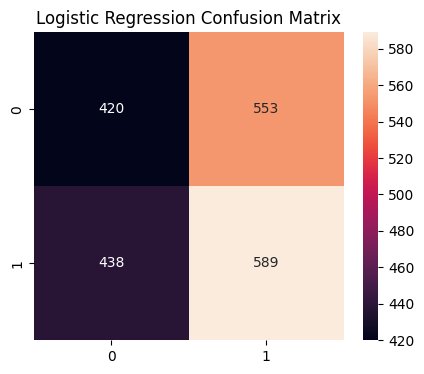

In [ ]:
# Confusion Matrix

cm = confusion_matrix(y_test,pred_lr)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

## Tokenization and Padding for Deep Learning

In [ ]:
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)
max_len = 200
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

NameError: name 'Tokenizer' is not defined

# CNN Model

In [ ]:
cnn_model = Sequential()

cnn_model.add(Embedding(10000,128,input_length=max_len))

cnn_model.add(Conv1D(128,5,activation='relu'))

cnn_model.add(GlobalMaxPooling1D())

cnn_model.add(Dense(64,activation='relu'))

cnn_model.add(Dense(1,activation='sigmoid'))

cnn_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
# Train CNN Model

history_cnn = cnn_model.fit(
    X_train_pad,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20


200/200 [==============================] - 8s 30ms/step - loss: 0.6957 - accuracy: 0.5041 - val_loss: 0.6952 - val_accuracy: 0.4894
Epoch 2/20
200/200 [==============================] - 6s 28ms/step - loss: 0.6941 - accuracy: 0.5047 - val_loss: 0.6988 - val_accuracy: 0.4756
Epoch 3/20
200/200 [==============================] - 6s 29ms/step - loss: 0.6927 - accuracy: 0.5184 - val_loss: 0.7023 - val_accuracy: 0.4669
Epoch 4/20
200/200 [==============================] - 5s 26ms/step - loss: 0.6929 - accuracy: 0.5092 - val_loss: 0.6953 - val_accuracy: 0.4844
Epoch 5/20
200/200 [==============================] - 5s 26ms/step - loss: 0.6918 - accuracy: 0.5231 - val_loss: 0.6996 - val_accuracy: 0.4700
Epoch 6/20
200/200 [==============================] - 5s 25ms/step - loss: 0.6916 - accuracy: 0.5184 - val_loss: 0.6958 - val_accuracy: 0.4931
Epoch 7/20
200/200 [==============================] - 5s 26ms/step - loss: 0.6915 - accuracy: 0.5209 - val_loss: 0.6995 - val_accuracy: 0.47

KeyboardInterrupt: 

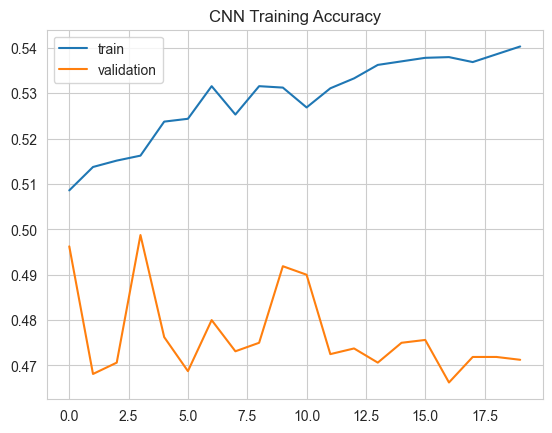

In [ ]:
# CNN Accuracy Graph

plt.plot(history_cnn.history['accuracy'])
plt.plot(history_cnn.history['val_accuracy'])

plt.title("CNN Training Accuracy")

plt.legend(['train','validation'])

plt.show()

# BiLSTM Model

In [ ]:
bilstm_model = Sequential()

bilstm_model.add(Embedding(10000,128,input_length=max_len))

bilstm_model.add(Bidirectional(LSTM(64)))

bilstm_model.add(Dense(64,activation='relu'))

bilstm_model.add(Dense(1,activation='sigmoid'))

bilstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
history_lstm = bilstm_model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
200/200 [==============================] - 11s 45ms/step - loss: 0.6937 - accuracy: 0.5097 - val_loss: 0.6931 - val_accuracy: 0.5025
Epoch 2/5
200/200 [==============================] - 8s 41ms/step - loss: 0.6931 - accuracy: 0.5111 - val_loss: 0.6943 - val_accuracy: 0.4750
Epoch 3/5
200/200 [==============================] - 8s 41ms/step - loss: 0.6926 - accuracy: 0.5172 - val_loss: 0.6964 - val_accuracy: 0.4831
Epoch 4/5
200/200 [==============================] - 8s 41ms/step - loss: 0.6924 - accuracy: 0.5167 - val_loss: 0.6981 - val_accuracy: 0.4794
Epoch 5/5
200/200 [==============================] - 8s 41ms/step - loss: 0.6915 - accuracy: 0.5300 - val_loss: 0.6948 - val_accuracy: 0.4931


## Model Performance Comparison

63/63 [==============================] - 1s 13ms/step - loss: 0.6950 - accuracy: 0.5075


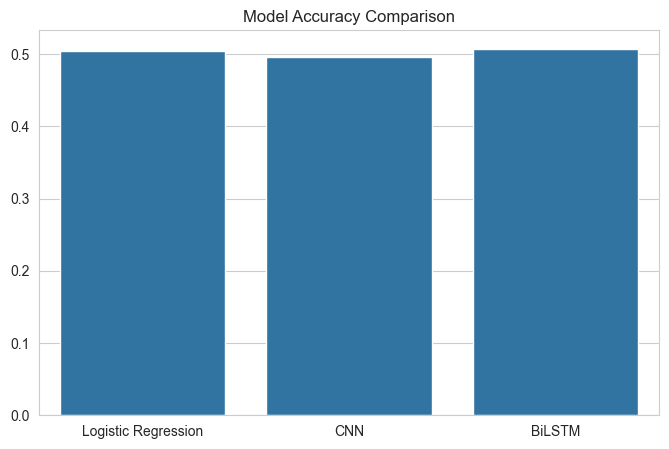

In [ ]:
acc_lr = accuracy_score(y_test,pred_lr)

acc_cnn = cnn_model.evaluate(X_test_pad,y_test)[1]

acc_lstm = bilstm_model.evaluate(X_test_pad,y_test)[1]

models = ['Logistic Regression','CNN','BiLSTM']

accuracy = [acc_lr,acc_cnn,acc_lstm]

plt.figure(figsize=(8,5))

sns.barplot(x=models,y=accuracy)

plt.title("Model Accuracy Comparison")

plt.show()

In [ ]:
results = pd.DataFrame({
    'Model':models,
    'Accuracy':accuracy
})

results

,Model,Accuracy
0,Logistic Regression,0.5045
1,CNN,0.4955
2,BiLSTM,0.5075


In [ ]:
bilstm_model.save("../models/ai_models/bilstm_ai_model.h5")

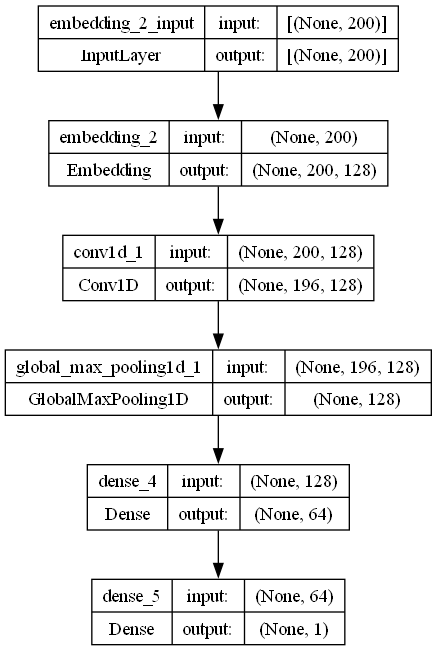

In [ ]:
from tensorflow.keras.utils import plot_model

plot_model(cnn_model,
           to_file='cnn_architecture.png',
           show_shapes=True,
           show_layer_names=True)

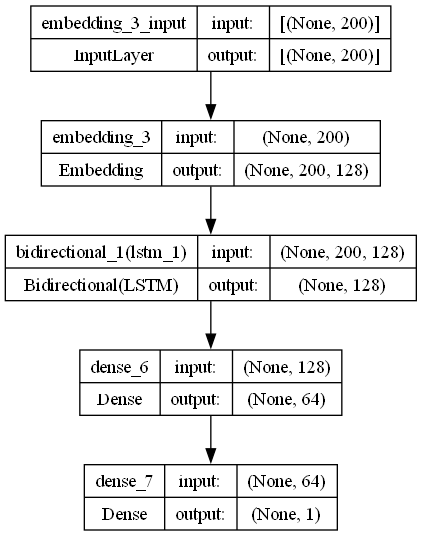

In [ ]:
plot_model(bilstm_model,
           to_file='bilstm_architecture.png',
           show_shapes=True)